In [2]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.datasets import fetch_lfw_people

# Add download_if_missing=False to use cached version if interrupted
# Or set a timeout to prevent hanging
import time
start_time = time.time()

faces = fetch_lfw_people(min_faces_per_person=100)

elapsed_time = time.time() - start_time
print(f"Download/Load time: {elapsed_time:.2f} seconds")
print(f"Target names: {faces.target_names}")
print(f"Images shape: {faces.images.shape}")

Download/Load time: 0.14 seconds
Target names: ['Colin Powell' 'Donald Rumsfeld' 'George W Bush' 'Gerhard Schroeder'
 'Tony Blair']
Images shape: (1140, 62, 47)


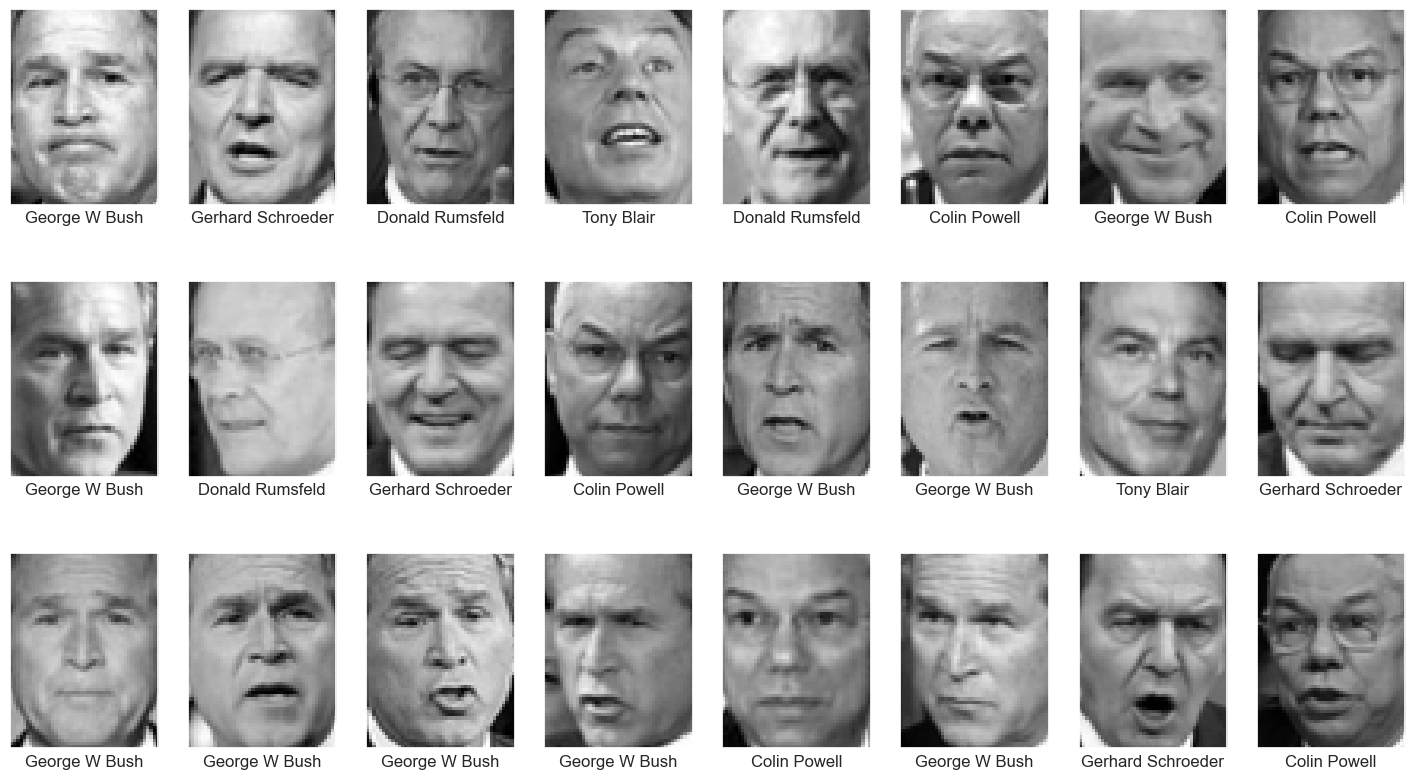

In [3]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots(3,8 , figsize =(18,10))
for i,axi in enumerate(ax.flat):
    axi.imshow(faces.images[i],cmap = 'gist_gray')
    axi.set(xticks =[], yticks =[],xlabel = faces.target_names[faces.target[i]])


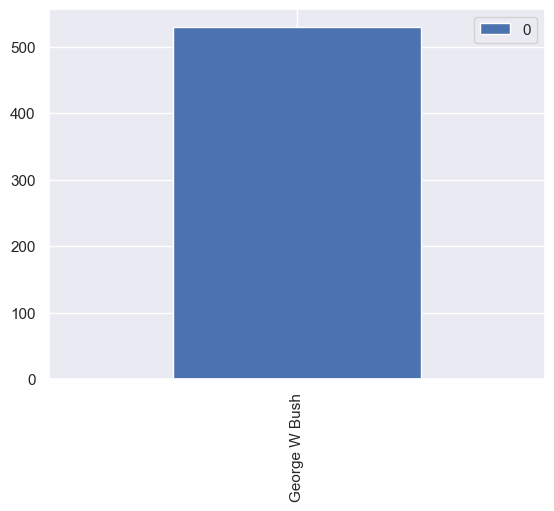

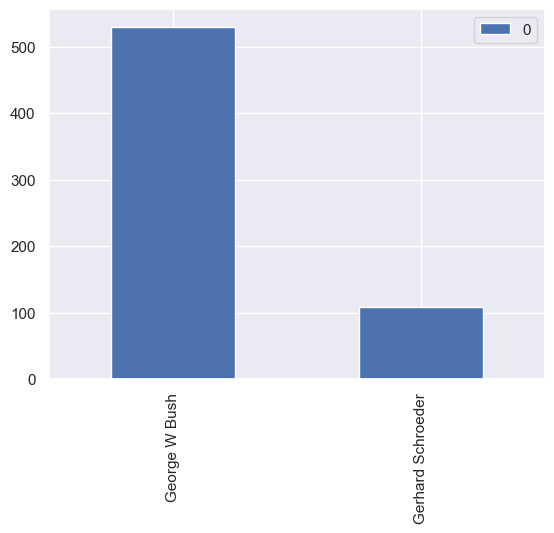

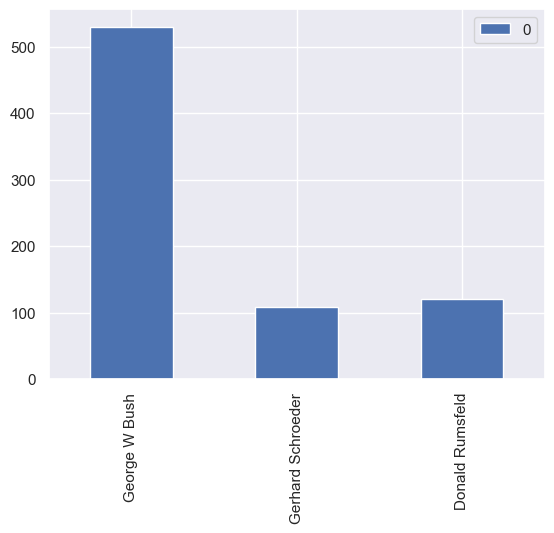

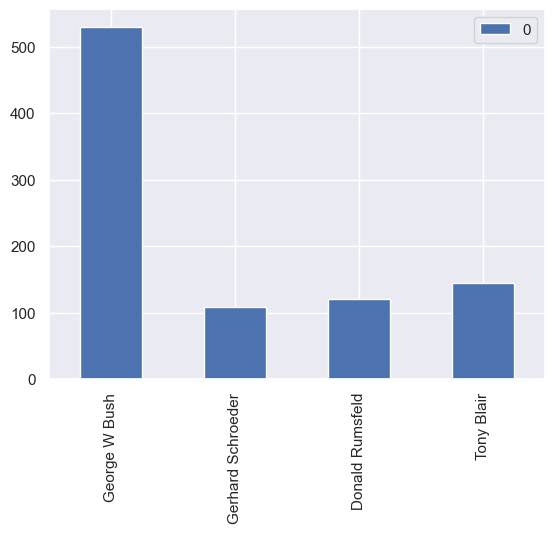

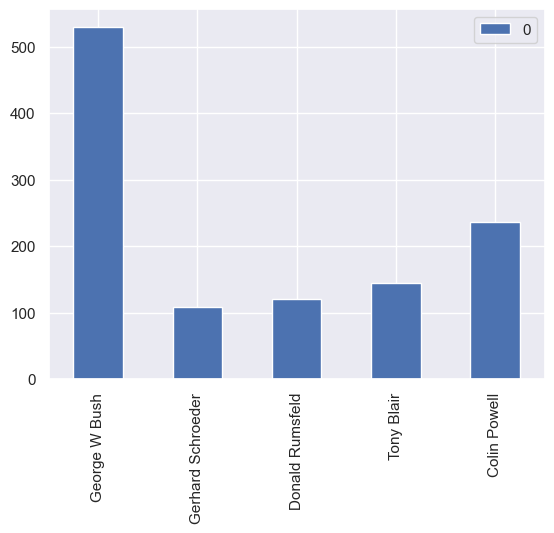

In [7]:
import seaborn as sns
sns.set()

from collections import Counter
counts = Counter(faces.target)
names = {}

for key in counts.keys():
    names[faces.target_names[key]] = counts[key]

    df =pd.DataFrame.from_dict(names, orient ='index')
    df.plot(kind ='bar')

In [8]:
mask = np.zeros(faces.target.shape,dtype=bool)

for target in np.unique(faces.target):
    mask[np.where(faces.target==target)[0][:100]]=1

x= faces.data[mask]
y=faces.target[mask]
x.shape


(500, 2914)

In [12]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

svc = SVC(kernel = 'linear')
grid= {
    'C':[0.1,1,10,100]
    }
grid_search = GridSearchCV (estimator=svc,param_grid=grid,cv = 5 ,verbose = 2)
grid_search.fit(x,y)
grid_search.best_score_

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV] END ..............................................C=0.1; total time=   0.1s
[CV] END ..............................................C=0.1; total time=   0.0s
[CV] END ..............................................C=0.1; total time=   0.0s
[CV] END ..............................................C=0.1; total time=   0.0s
[CV] END ..............................................C=0.1; total time=   0.0s
[CV] END ................................................C=1; total time=   0.0s
[CV] END ................................................C=1; total time=   0.0s
[CV] END ................................................C=1; total time=   0.0s
[CV] END ................................................C=1; total time=   0.0s
[CV] END ................................................C=1; total time=   0.0s
[CV] END ...............................................C=10; total time=   0.0s
[CV] END ........................................

np.float64(0.844)

In [13]:
grid_search.best_params_

{'C': 0.1}

In [10]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
svc = SVC(kernel ='linear')
pipe = make_pipeline(scaler,svc)

grid = {
    'svc__C':[0.1,1,10,100]
}

grid_search = GridSearchCV (estimator=pipe,param_grid=grid,cv = 5 ,verbose = 2)
grid_search.fit(x,y)
grid_search.best_score_

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV] END .........................................svc__C=0.1; total time=   0.1s
[CV] END .........................................svc__C=0.1; total time=   0.1s
[CV] END .........................................svc__C=0.1; total time=   0.1s
[CV] END .........................................svc__C=0.1; total time=   0.1s
[CV] END .........................................svc__C=0.1; total time=   0.1s
[CV] END ...........................................svc__C=1; total time=   0.1s
[CV] END ...........................................svc__C=1; total time=   0.0s
[CV] END ...........................................svc__C=1; total time=   0.1s
[CV] END ...........................................svc__C=1; total time=   0.1s
[CV] END ...........................................svc__C=1; total time=   0.1s
[CV] END ..........................................svc__C=10; total time=   0.1s
[CV] END ........................................

np.float64(0.8619999999999999)

In [11]:
grid_search.best_params_

{'svc__C': 0.1}

In [15]:
scaler = StandardScaler()
svc = SVC(kernel ='poly')
pipe = make_pipeline(scaler,svc)

grid = {
    'svc__C':[0.01,0.1,1,10,100],
    'svc__gamma':[0.01,0.25,0.5,0.75,1],
    'svc__degree':[1,2,3,4,5]
}

grid_search = GridSearchCV (estimator=pipe,param_grid=grid,cv = 5 ,verbose = 2)
grid_search.fit(x,y)
grid_search.best_score_

Fitting 5 folds for each of 125 candidates, totalling 625 fits
[CV] END ........svc__C=0.01, svc__degree=1, svc__gamma=0.01; total time=   0.1s
[CV] END ........svc__C=0.01, svc__degree=1, svc__gamma=0.01; total time=   0.1s
[CV] END ........svc__C=0.01, svc__degree=1, svc__gamma=0.01; total time=   0.1s
[CV] END ........svc__C=0.01, svc__degree=1, svc__gamma=0.01; total time=   0.1s
[CV] END ........svc__C=0.01, svc__degree=1, svc__gamma=0.01; total time=   0.1s
[CV] END ........svc__C=0.01, svc__degree=1, svc__gamma=0.25; total time=   0.0s
[CV] END ........svc__C=0.01, svc__degree=1, svc__gamma=0.25; total time=   0.0s
[CV] END ........svc__C=0.01, svc__degree=1, svc__gamma=0.25; total time=   0.0s
[CV] END ........svc__C=0.01, svc__degree=1, svc__gamma=0.25; total time=   0.0s
[CV] END ........svc__C=0.01, svc__degree=1, svc__gamma=0.25; total time=   0.0s
[CV] END .........svc__C=0.01, svc__degree=1, svc__gamma=0.5; total time=   0.0s
[CV] END .........svc__C=0.01, svc__degree=1, 

np.float64(0.8619999999999999)